# find more cPeaks

## train

In [1]:
import sys
sys.path.append('/nfs/public/wxz/Consensus_peak_v2/github/deepCNN/')

from DeepCNN import *
from tools import *

setup_seed(2024)
lr = 0.001
batch_size = 64
num_workers = 64

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
pos_fa_file = '/nfs/public/wxz/Consensus_peak_v2/github/deepCNN/data/pos_filterN.fa'
neg_fa_file = '/nfs/public/wxz/Consensus_peak_v2/github/deepCNN/data/neg_filterN.fa'

import done!


In [2]:
model = DeepCNN(n_cells=2)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

dataset = ChromosomeDataset_Train(pos_fa_file,neg_fa_file)

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

fasta loaded!


In [3]:
num_epochs = 10
train_res = []
val_res = []
for epoch in range(num_epochs):
    train_res.append(train_aug(model, train_loader, optimizer, criterion, device))
    val_res.append(test(model, val_loader, criterion, device))
    torch.save(model,f'./save_model/predict_cpeaks_epoch{epoch+1}.pt')

Train Loss: 0.4787, Acc: 0.8249, Precision: 0.8250, Recall: 0.8249, F1: 0.8249, AUC: 0.9049
Test Loss: 0.4759, Acc: 0.8281, Precision: 0.8451, Recall: 0.8281, F1: 0.8257, AUC: 0.9292
Train Loss: 0.4494, Acc: 0.8566, Precision: 0.8567, Recall: 0.8566, F1: 0.8566, AUC: 0.9313
Test Loss: 0.4496, Acc: 0.8560, Precision: 0.8607, Recall: 0.8560, F1: 0.8554, AUC: 0.9374
Train Loss: 0.4409, Acc: 0.8658, Precision: 0.8659, Recall: 0.8658, F1: 0.8658, AUC: 0.9378
Test Loss: 0.4468, Acc: 0.8595, Precision: 0.8647, Recall: 0.8595, F1: 0.8589, AUC: 0.9402
Train Loss: 0.4347, Acc: 0.8727, Precision: 0.8727, Recall: 0.8727, F1: 0.8727, AUC: 0.9422
Test Loss: 0.4384, Acc: 0.8688, Precision: 0.8703, Recall: 0.8688, F1: 0.8686, AUC: 0.9421
Train Loss: 0.4295, Acc: 0.8784, Precision: 0.8784, Recall: 0.8784, F1: 0.8784, AUC: 0.9454
Test Loss: 0.4454, Acc: 0.8611, Precision: 0.8667, Recall: 0.8611, F1: 0.8604, AUC: 0.9417
Train Loss: 0.4251, Acc: 0.8834, Precision: 0.8835, Recall: 0.8834, F1: 0.8834, AUC: 

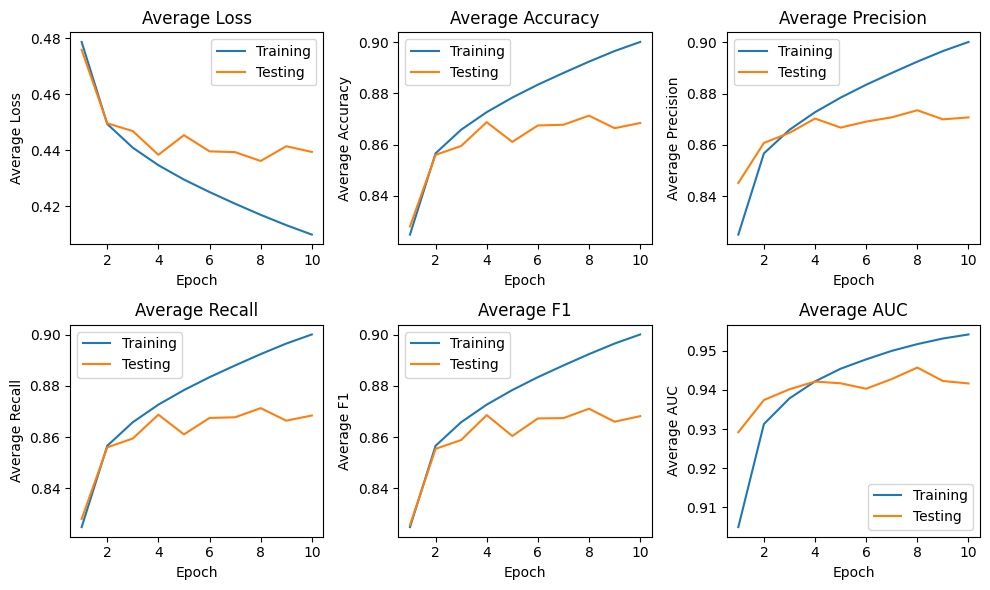

In [4]:
plot_res(train_res,val_res,num_epochs)

## get best epoch and test

In [5]:
idx = np.argmin(np.array(val_res)[:,0])
print(f'best epoch is {idx+1}')

best epoch is 8


In [6]:
model = torch.load(f'./save_model/predict_cpeaks_epoch{idx+1}.pt')
test(model, test_loader, criterion, device)

Test Loss: 0.4343, Acc: 0.8732, Precision: 0.8753, Recall: 0.8732, F1: 0.8729, AUC: 0.9468


(0.4343164531417856,
 0.8731693716432366,
 0.8753158360361963,
 0.8731693716432366,
 0.8729416942030934,
 0.9467661690697491)

## find more cPeaks

In [7]:
cadidate_path = './data/candidate.fa'
candidate_dataset = ChromosomeDataset_Test(cadidate_path)
candidate_dataloader = DataLoader(candidate_dataset, batch_size=64, shuffle=False,num_workers=64,pin_memory=True)

pre_candidate = []
peak_lst = []

with torch.no_grad():  
    for peak,inputs in tqdm(candidate_dataloader):
        
        inputs = inputs.to(device)
        outputs = model(inputs)
        pre_candidate.append(outputs.cpu().numpy()[:,1])
        peak_lst.append(peak)
        
pre_arr = np.concatenate(pre_candidate) 
peak_arr = np.concatenate(peak_lst)

fasta loaded!


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 99283/99283 [09:16<00:00, 178.51it/s]


In [8]:
root = './data/'
top = peak_arr[pre_arr.ravel()>0.87177]

with open(root+'tmp.bed','w') as f:
    f.write('\n'.join(top).replace('>','').replace(':','\t').replace('-','\t'))

!cat ./data/cpeaks_observed.bed ./data/tmp.bed > ./data/tmp2.bed
!bedtools sort -i ./data/tmp2.bed > ./data/tmp.bed
!bedtools merge -i ./data/tmp.bed > ./data/cpeak.all.bed

!rm ./data/tmp.bed
!rm ./data/tmp2.bed

# clsuter the shape

In [9]:
import sys
sys.path.append('/nfs/public/wxz/Consensus_peak_v2/github/deepCNN/')

from DeepCNN import *
from tools import *

setup_seed(2024)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = DeepCNN(n_cells=2,is_activate=False).to(device)

dataset = ChromosomeDataset_Train_shape('./data/encode_shape_sub.bed','./data/encode_shape_sub.fa')
batch_size = 128
num_workers = 64
lr = 0.0001

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr)

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

fasta loaded!


------------------------- epoch:  0 -------------------------
Label left:
  accuracy: 0.7678513205086404
  precision: [0.72463002 0.83744681]
  recall: [0.87772087 0.6538206 ]
  f1: [0.79386219 0.73432836]
  auc: 0.8711554740706395
Label right:
  accuracy: 0.7603521356374308
  precision: [0.76646707 0.7544757 ]
  recall: [0.75       0.77073808]
  f1: [0.75814413 0.76252019]
  auc: 0.8478274088966906
------------------------- epoch:  1 -------------------------
Label left:
  accuracy: 0.7870883599608738
  precision: [0.80523842 0.76996198]
  recall: [0.76760563 0.80730897]
  f1: [0.78597181 0.78819332]
  auc: 0.8757568667820879
Label right:
  accuracy: 0.7668731659602217
  precision: [0.71083719 0.86428571]
  recall: [0.90104167 0.63226649]
  f1: [0.7947172  0.73029046]
  auc: 0.8591810907903332
------------------------- epoch:  2 -------------------------
Label left:
  accuracy: 0.7896967720899902
  precision: [0.80105056 0.77849741]
  recall: [0.78104994 0.7986711 ]
  f1: [0.79092382 

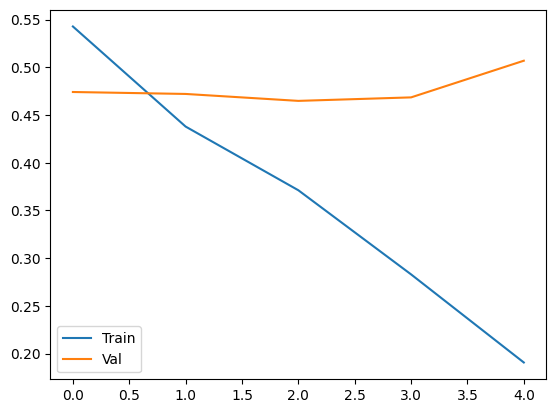

In [10]:
num_epoch = 5
train_loss,val_loss = [],[]
for e in range(num_epoch):
    print('-'*25,'epoch: ',e,'-'*25)
    train_loss.append(train_shape(model, train_loader, optimizer, criterion, device))
    val_loss.append(test_shape(model, val_loader, optimizer, criterion, device))
    torch.save(model,f'./save_model/predict_shape_epoch{e+1}.pt')
    
plt.plot(train_loss,label = 'Train')
plt.plot(val_loss,label = 'Val')
plt.legend()
plt.show()

In [11]:
idx = np.argmin(np.array(val_loss))
print(f'best epoch is {idx+1}')

model = torch.load(f'./save_model/predict_shape_epoch{idx+1}.pt')
test_loss = test_shape(model, test_loader, optimizer, criterion, device)

best epoch is 3
Label left:
  accuracy: 0.7973281199087651
  precision: [0.80250165 0.79225806]
  recall: [0.79104478 0.80366492]
  f1: [0.79673203 0.79792073]
  auc: 0.8729423676065382
Label right:
  accuracy: 0.7797328119908765
  precision: [0.77733333 0.78202677]
  recall: [0.77320955 0.78603459]
  f1: [0.77526596 0.78402556]
  auc: 0.8582278244409062
